In [45]:
import os
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import util.functions as functions
import pybamm
import numpy as np
from tqdm import trange
#os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".20"

In [46]:
from models.DON import DeepONet, generate_trunk_points
from util.FNO_util import train_test_split
from training.scheduler import cosine_schedule_with_warmup
from util.plotting import plot_losses

In [47]:
from util.postprocess import filter_anode_cathode

In [48]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600

In [49]:
# # Set random keys
# main_key = jax.random.PRNGKey(0)
# key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

# # Hyperparameters
# num_train = 2000
# num_test = 200
# batch_size = 32
# learning_rate = 1e-4
# num_epochs = 50

C = params_bat["Nominal cell capacity [A.h]"]    # example scalar for GaussianRFCurrent
t_max = 3600

In [ ]:
family = "GRF"
N_total = 2200
data = np.load(f"../data/{family}_{N_total}.npz") # Change to DON data
random_seed = 42
test_ratio = 0.1

In [51]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)  # noqa: F405

In [52]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])

###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])

In [53]:
train_soc = np.array(train_data["soc"])
test_soc = np.array(test_data["soc"])

In [54]:
cs_max_a_norm = 1
cs_max_c_norm = 1
cs_min_a_norm = 0
cs_min_c_norm = 0

In [55]:
train_cn_anode, train_cn_cathode, train_mask = filter_anode_cathode(train_cn_anode, train_cn_cathode,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [56]:
test_cn_anode, test_cn_cathode, test_mask = filter_anode_cathode(test_cn_anode, test_cn_cathode,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [57]:
train_I = train_I[train_mask]
test_I = test_I[test_mask]
train_c0_anode = train_c0_anode[train_mask]
test_c0_anode = test_c0_anode[test_mask]
train_c0_cathode = train_c0_cathode[train_mask]
test_c0_cathode = test_c0_cathode[test_mask]

train_soc = train_soc[train_mask]
test_soc = test_soc[test_mask]

In [58]:
train_I.shape

(1644, 75)

In [59]:
def data_loader(train_I, train_c0, train_cn, trunk_points, batch_size):
    """
    A simple data loader generator that yields batches of training data.
    
    Parameters
    ----------
    train_I : np.ndarray or jnp.ndarray
        Current samples array of shape (num_train, 75).
    train_c0 : np.ndarray or jnp.ndarray
        Initial concentration array of shape (num_train, 20).
    train_cn : np.ndarray or jnp.ndarray
        Target concentrations array of shape (num_train, 20, 75).
    trunk_points : np.ndarray or jnp.ndarray
        Fixed trunk points array of shape (20*75, 2), or generally (r_len*t_len, 2).
    batch_size : int
        Number of samples per batch.

    Yields
    ------
    (I_batch, c0_batch, trunk_points, cn_batch) : tuple of jnp.ndarray
        I_batch : (batch_size, 75)
        c0_batch : (batch_size, 20)
        trunk_points : (1500, 2) - same for every batch
        cn_batch : (batch_size, 20, 75)
    """
    num_samples = train_I.shape[0]


    # Shuffle indices
    permutation = np.random.permutation(num_samples)

    for start_idx in range(0, num_samples, batch_size):
        batch_indices = permutation[start_idx:start_idx+batch_size]

        I_batch = train_I[batch_indices]       # (batch_size, 75)
        c0_batch = train_c0[batch_indices]     # (batch_size, 20)
        cn_batch = train_cn[batch_indices]     # (batch_size, 20, 75)
        
        # trunk_points are the same for each batch
        yield I_batch, c0_batch, trunk_points, cn_batch

In [60]:
width = 500
depth = 11
amount_basis = 64
num_samples_I = 75
num_samples_c0 = 20
K = num_samples_I * num_samples_c0
t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [61]:
trunk_points = generate_trunk_points(r, t/t_max)

In [62]:
# Setup model hyperparameters
branch_layers = [width] * depth + [amount_basis]  # M = 200 at the end
trunk_layers = branch_layers

model = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(random_seed))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params = model.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model.apply(params, dummy_I, dummy_c0, dummy_trunk_input)

print("Output shape:", output.shape)


Output shape: (1500,)


In [63]:
codomainsize = output.shape[0]

In [64]:
def single_forward(params, I_single, c0_single, trunk_points):
    # params: model parameters
    # I_single: (85,)
    # c0_single: (20,)
    # trunk_points: (K, 2)
    return model.apply(params, I_single, c0_single, trunk_points)

batch_forward = jax.vmap(
    single_forward,
    in_axes=(None, 0, 0, None),  # params and trunk_points have no batch axis
    out_axes=0
)

def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.mean(target.flatten() ** 2)

    norm_diff = jnp.mean((pred.flatten() - target.flatten()) ** 2)

    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-6, norm_target)
    return norm_diff / norm_target

def rmse(pred, target):
    # pred and target: (K,) arrays
    norm_diff = jnp.mean((pred.flatten() - target.flatten()) ** 2)
    # Handle the case when target is all zeros
    # print(target.flatten())
    # print(pred.flatten())

    return norm_diff


def loss_fn(params, I_batch, c0_batch, trunk_pts, cn_batch):
    # pred: (batch, K)
    pred = batch_forward(params, I_batch, c0_batch, trunk_pts)
    # Apply single_sample_loss to each (pred[i], cn_batch[i]) pair
    loss = relative_l2_loss(pred, cn_batch)
    # loss = rmse(pred, cn_batch)
    return loss

In [65]:
num_epochs = 200
batch_size = 20

warmup_steps = N_total/batch_size         # ~1 epoch
print("Warmup steps:", warmup_steps)
peak_lr = 1e-2                  # try bigger than your current 4e-3
total_steps = 25 * warmup_steps       # ~293,350
end_lr = 1e-4                   # final LR

scheduler = cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

optimizer = optax.adam(scheduler)
# Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

# Setup optimizer (Adam)

# learning_rate = 4e-3
# optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


Warmup steps: 110.0


In [66]:
@jax.jit
def train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch):

    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, I_batch, c0_batch, trunk_pts, cn_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [67]:
train_losses = []
test_losses = []

pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    # Training phase
    total_train_loss = 0.0
    count = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(train_I, train_c0_anode, train_cn_anode, trunk_points, batch_size):
        # targets_flat = cn_batch.reshape(cn_batch.shape[0], -1)
        # loss_value, grads = jax.value_and_grad(loss_fn)(params, I_batch, c0_batch, trunk_pts, targets_flat)
        # updates, opt_state = optimizer.update(grads, opt_state)
        # params = optax.apply_updates(params, updates)

        params, opt_state, loss_value = train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch)
        if loss_value > 1e3:
            #print(f"Warning: High loss value detected: {loss_value:.4f} at epoch {epoch+1}")
            loss_value = 1.
        #print(f"Epoch {epoch+1}, Batch Loss: {loss_value:.4f}")        
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(test_I, test_c0_anode, test_cn_anode, trunk_points, batch_size):
        loss_value_test = loss_fn(params, I_batch, c0_batch, trunk_pts, cn_batch)
        total_test_loss += loss_value_test
        count2 += 1

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)


Epoch 200/200 | Train Loss: 0.0015 | Test Loss: 0.0016: 100%|██████████| 200/200 [04:17<00:00,  1.29s/it]


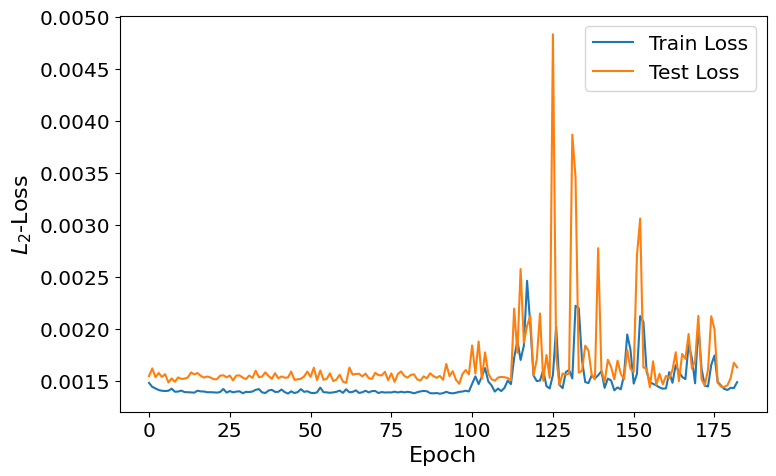

In [68]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses[17:], test_losses[17:])

In [69]:
N_train_filtered = train_I.shape[0]
N_test_filtered = test_I.shape[0]

In [70]:
train_idx = np.random.randint(0, N_train_filtered)
test_idx = np.random.randint(0, N_test_filtered)

In [71]:
c_train_true_anode = train_cn_anode[train_idx]
c_train_pred_anode = model.apply(params,train_I[train_idx],train_c0_anode[train_idx], trunk_points)

c_test_true_anode = test_cn_anode[test_idx]
c_test_pred_anode = model.apply(params,test_I[test_idx],test_c0_anode[test_idx], trunk_points)


In [72]:
# Reshape the training true and predicted concentration
lenr = r.shape[0]
lent = t.shape[0]

c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

c_train_true_reshaped_anode = c_train_true_anode.reshape(lenr, lent) * c_max
c_train_pred_reshaped_anode = c_train_pred_anode.reshape(lenr, lent) * c_max

# Reshape the test true and predicted concentrations
c_test_true_reshaped_anode = c_test_true_anode.reshape(lenr, lent) * c_max
c_test_pred_reshaped_anode = c_test_pred_anode.reshape(lenr, lent) * c_max

In [73]:
train_error_line = jnp.mean(jnp.abs(c_train_pred_reshaped_anode - c_train_true_reshaped_anode), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_reshaped_anode - c_test_true_reshaped_anode), axis=0)      # shape (75,)

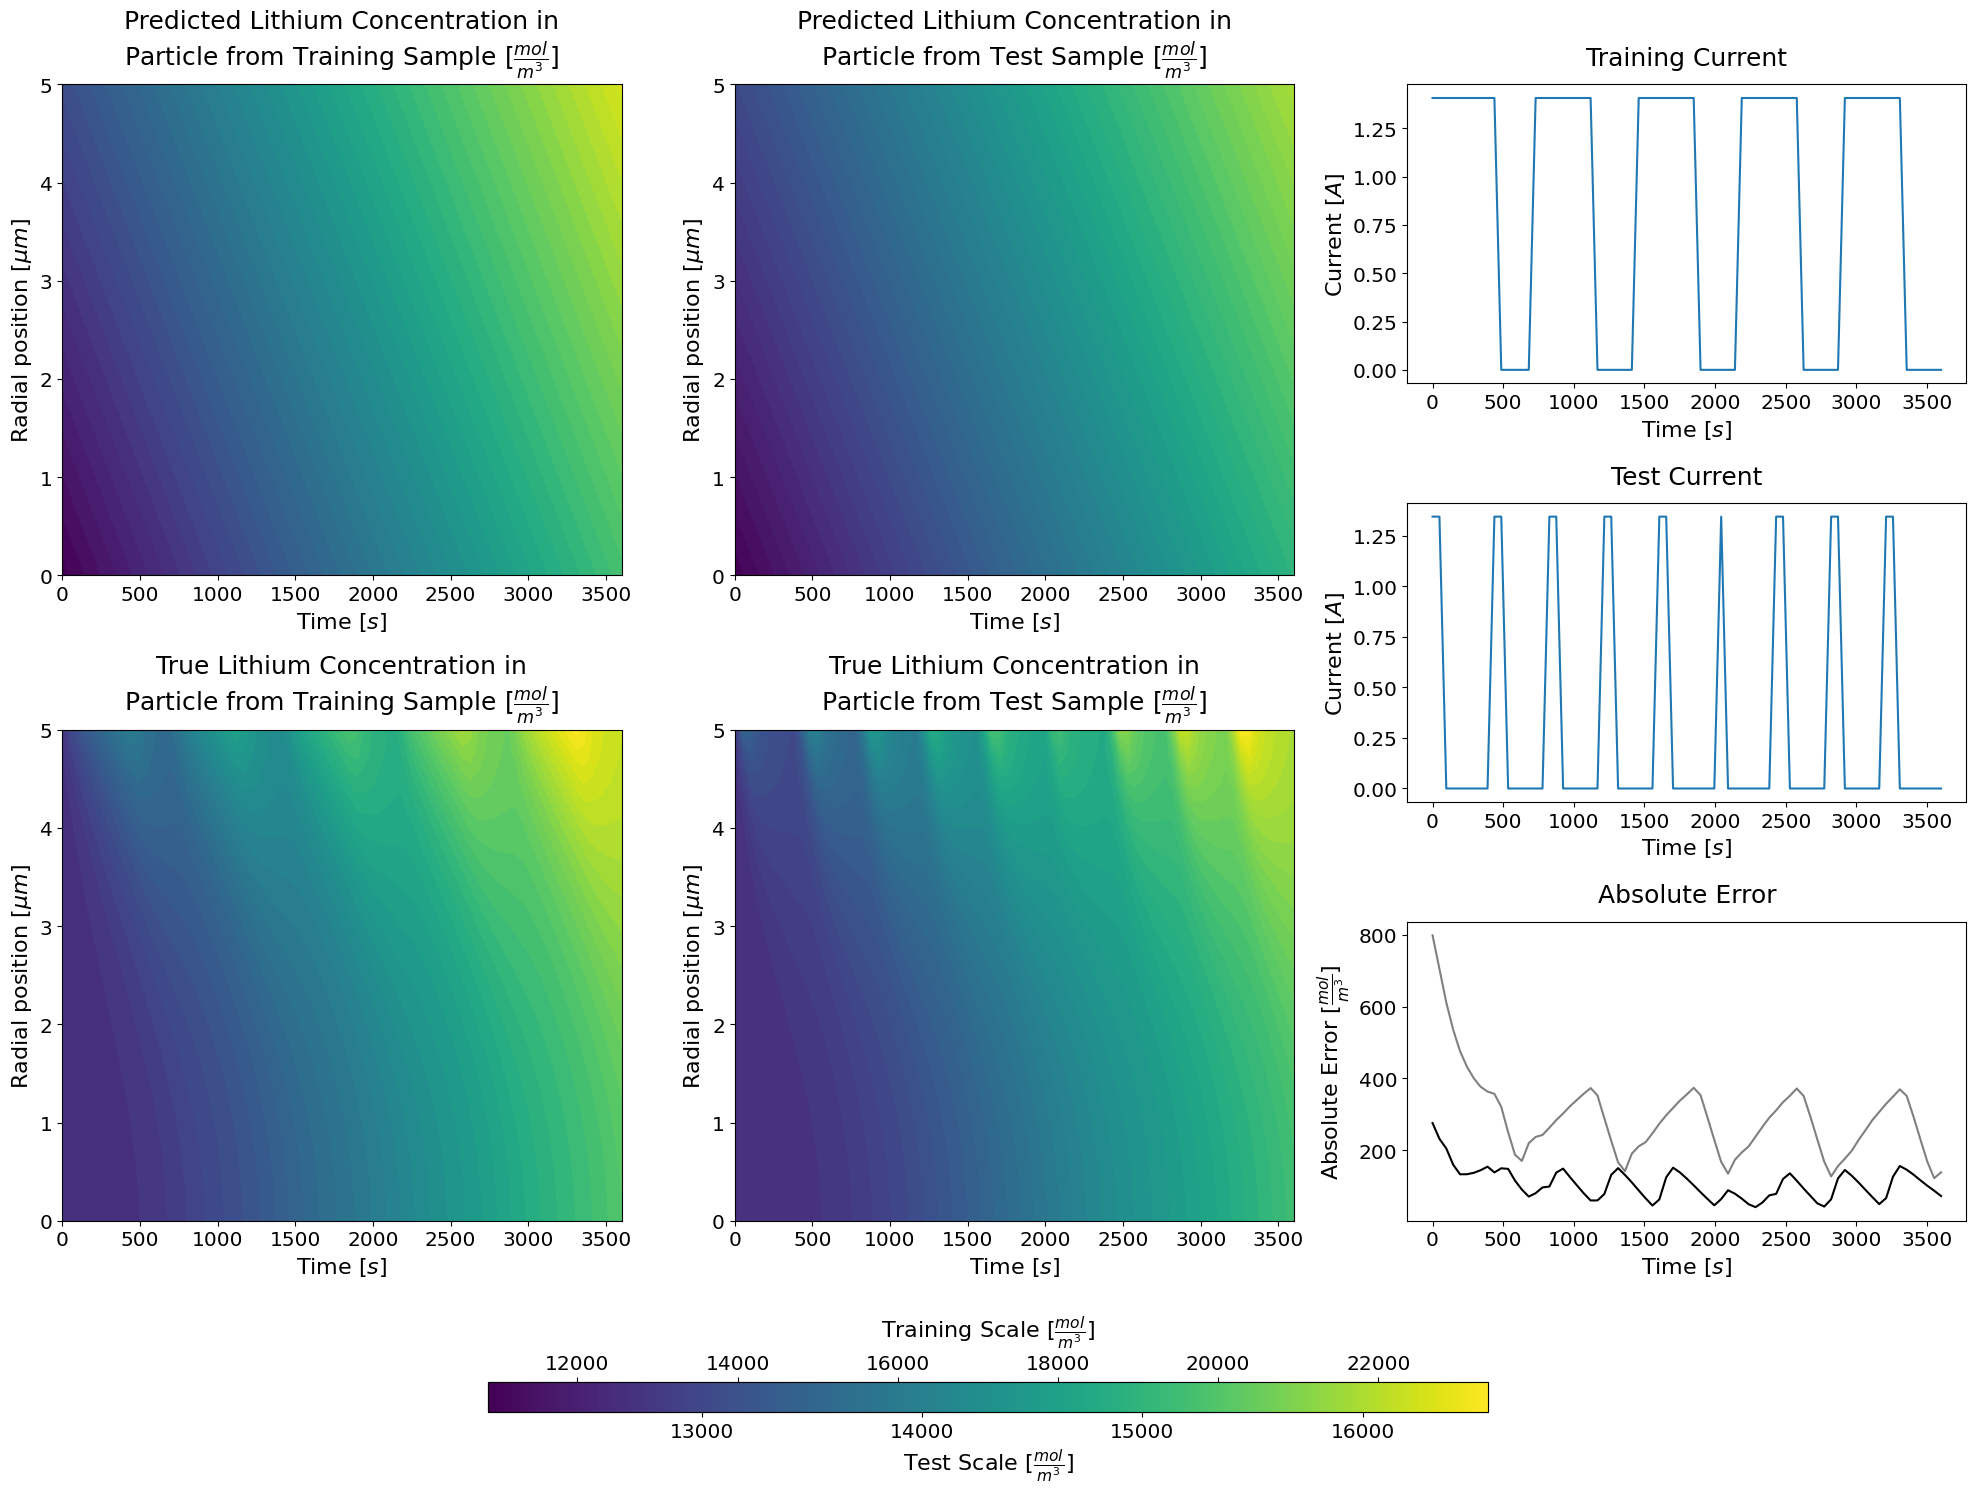

In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_plot = np.linspace(0,t_max,75)

T_plot, R_plot = jnp.meshgrid(t_plot, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_reshaped_anode.ravel(),
    c_train_true_reshaped_anode.ravel()
])
c_data = np.concatenate([
    c_test_pred_reshaped_anode.ravel(),
    c_test_true_reshaped_anode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_reshaped_anode,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_reshaped_anode,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_reshaped_anode,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_reshaped_anode,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t_plot, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t_plot, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t_plot, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

#figurename = "2DDONGRFBigPlot" + str(train_idx)
# Save as rasterized SVG with a chosen DPI
#fig.savefig(figurename + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [75]:
filename = functions.save_model_params(params, directory = "./trained_models/DON", family = family)

Saved model parameters to ./trained_models/DON/anode_PLS_2025-06-10_13-11-59.msgpack


In [76]:
model = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(0))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params = model.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model.apply(params, dummy_I, dummy_c0, dummy_trunk_input)

In [77]:
train_losses = []
test_losses = []

pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    # Training phase
    total_train_loss = 0.0
    count = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(train_I, train_c0_cathode, train_cn_cathode, trunk_points, batch_size):
        # targets_flat = cn_batch.reshape(cn_batch.shape[0], -1)
        # loss_value, grads = jax.value_and_grad(loss_fn)(params, I_batch, c0_batch, trunk_pts, targets_flat)
        # updates, opt_state = optimizer.update(grads, opt_state)
        # params = optax.apply_updates(params, updates)

        params, opt_state, loss_value = train_step(params, opt_state, I_batch, c0_batch, trunk_pts, cn_batch)
        #print(f"Epoch {epoch+1}, Batch Loss: {loss_value:.4f}")        
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for I_batch, c0_batch, trunk_pts, cn_batch in data_loader(test_I, test_c0_cathode, test_cn_cathode, trunk_points, batch_size):
        loss_value_test = loss_fn(params, I_batch, c0_batch, trunk_pts, cn_batch)
        total_test_loss += loss_value_test
        count2 += 1

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 200/200 | Train Loss: 0.0018 | Test Loss: 0.0018: 100%|██████████| 200/200 [04:04<00:00,  1.22s/it]


In [78]:
filename = functions.save_model_params(params, directory = "./trained_models/DON", family = family, prefix="cathode")

Saved model parameters to ./trained_models/DON/cathode_PLS_2025-06-10_13-16-03.msgpack


In [79]:
c_train_true_cathode = train_cn_cathode[train_idx]
c_train_pred_cathode = model.apply(params,train_I[train_idx],train_c0_cathode[train_idx], trunk_points)

c_test_true_cathode = test_cn_cathode[test_idx]
c_test_pred_cathode = model.apply(params,test_I[test_idx],test_c0_cathode[test_idx], trunk_points)


In [80]:
# Reshape the training true and predicted concentration
lenr = r.shape[0]
lent = t.shape[0]

c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

c_train_true_reshaped_cathode = c_train_true_cathode.reshape(lenr, lent) * c_max
c_train_pred_reshaped_cathode = c_train_pred_cathode.reshape(lenr, lent) * c_max

# Reshape the test true and predicted concentrations
c_test_true_reshaped_cathode = c_test_true_cathode.reshape(lenr, lent) * c_max
c_test_pred_reshaped_cathode = c_test_pred_cathode.reshape(lenr, lent) * c_max

In [ ]:
train_error_line = jnp.mean(jnp.abs(c_train_pred_reshaped_cathode - c_train_true_reshaped_cathode), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_reshaped_cathode - c_test_true_reshaped_cathode), axis=0)     # shape (75,)

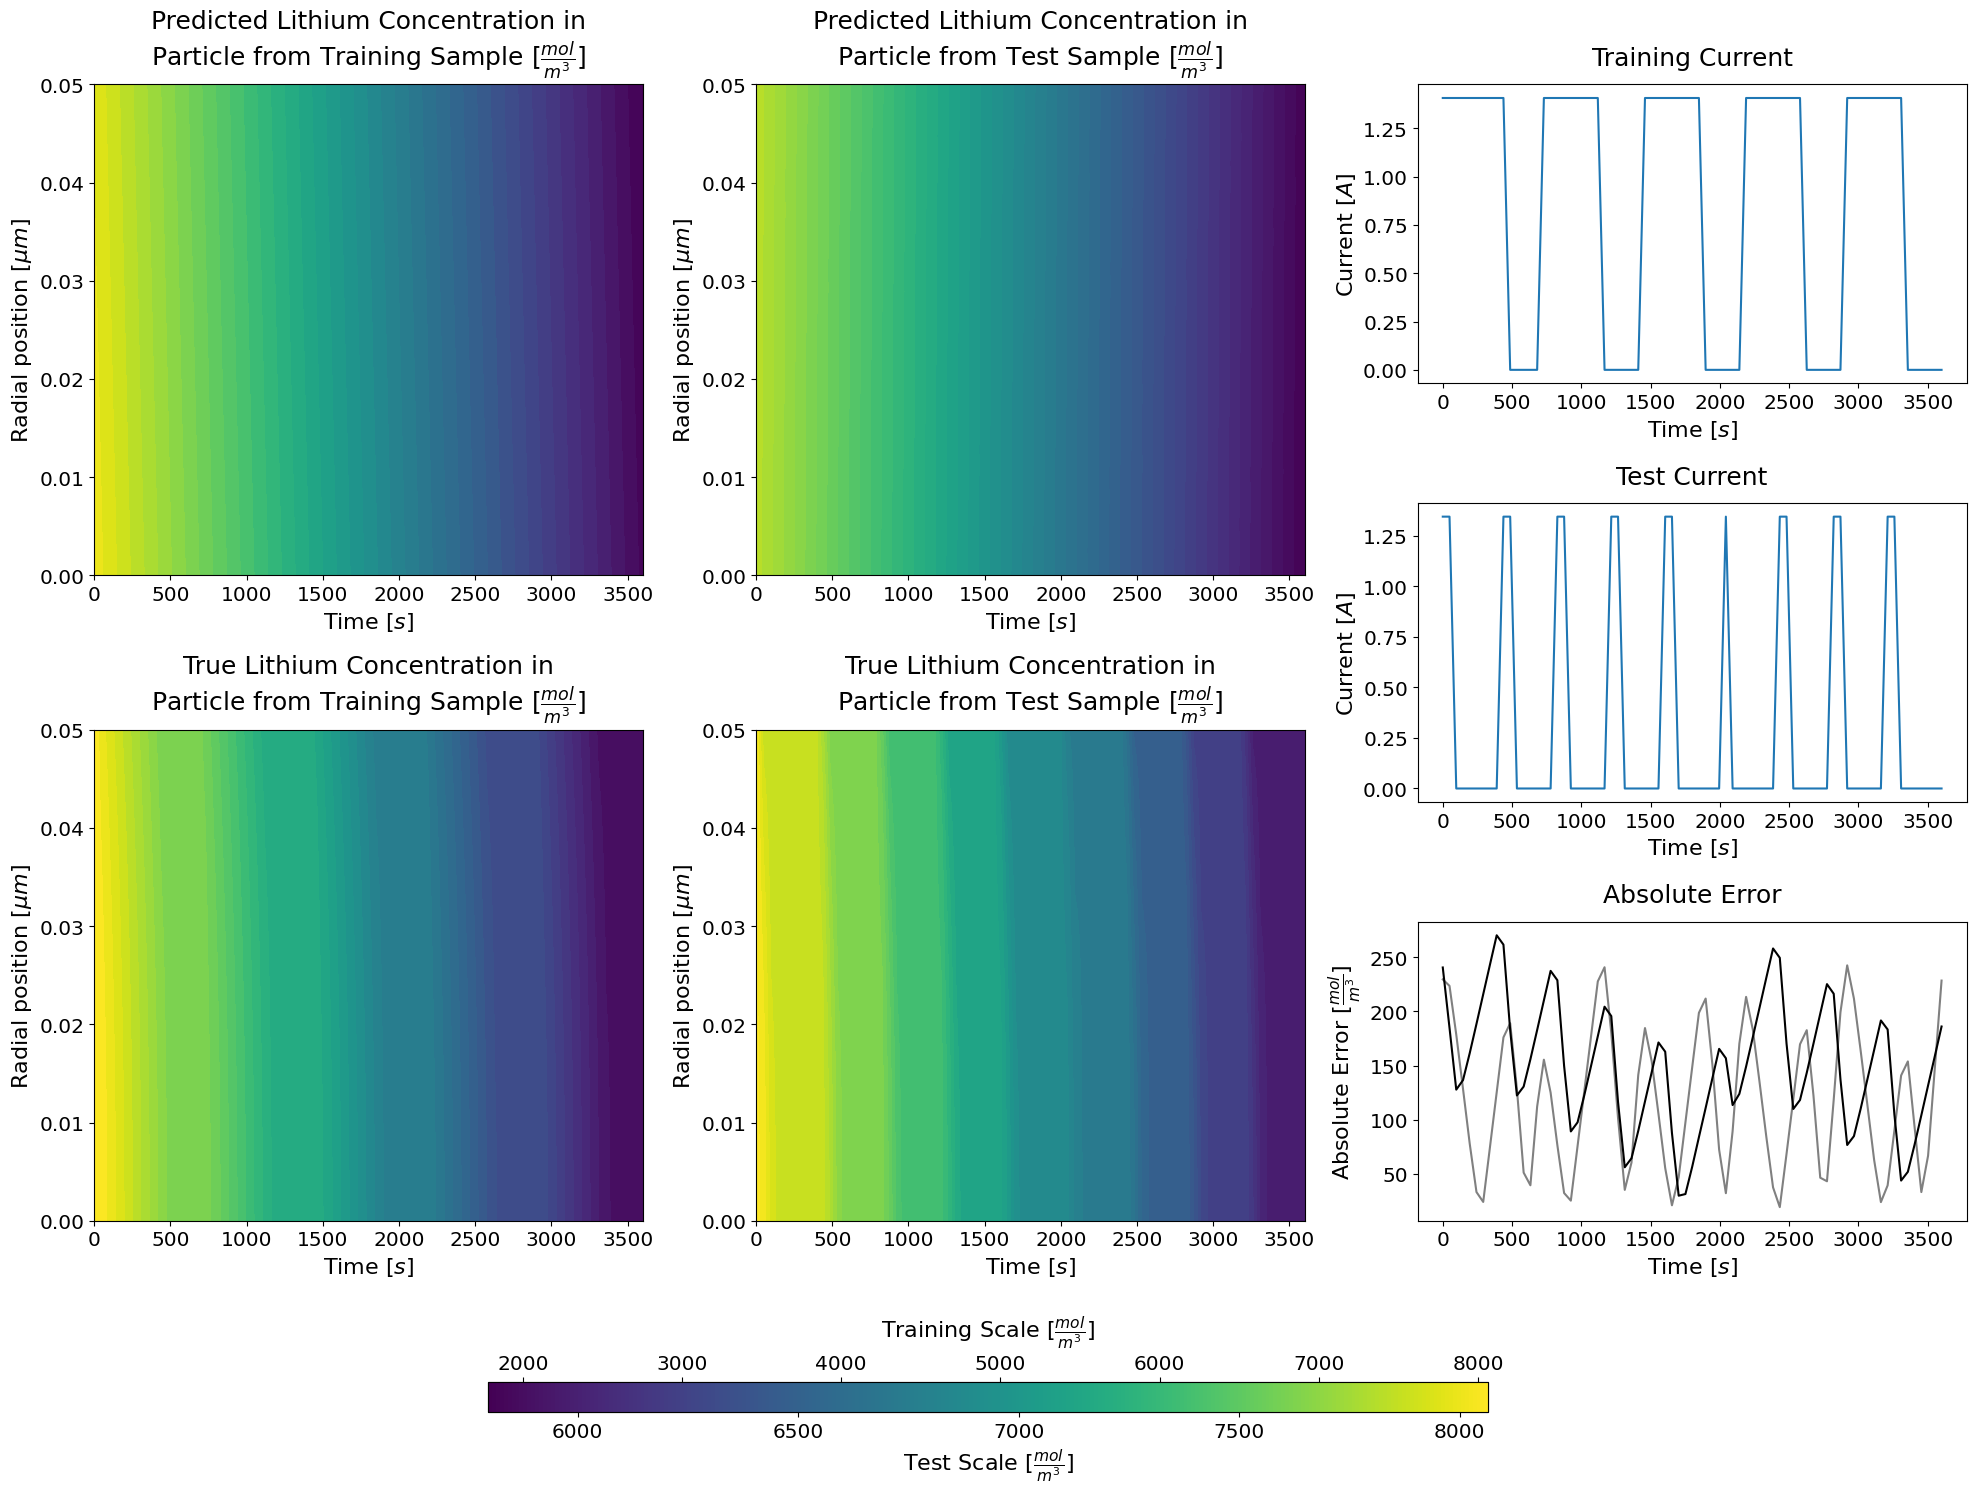

In [82]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_plot = np.linspace(0,t_max,75)

T_plot, R_plot = jnp.meshgrid(t_plot, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_reshaped_cathode.ravel(),
    c_train_true_reshaped_cathode.ravel()
])
c_data = np.concatenate([
    c_test_pred_reshaped_cathode.ravel(),
    c_test_true_reshaped_cathode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Rca*1e6, c_train_pred_reshaped_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Rca*1e6, c_train_true_reshaped_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
# rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Rca*1e6, c_test_pred_reshaped_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Rca*1e6, c_test_true_reshaped_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
# rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t_plot, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t_plot, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t_plot, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

#figurename = "2DDONGRFBigPlot" + str(train_idx)
# Save as rasterized SVG with a chosen DPI
#fig.savefig(figurename + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()